In [1]:
import torch
import os
from pathlib import Path
import logging
import numpy as np
import time
from torch_geometric.explain import GNNExplainer, Explainer, PGExplainer
from torch_geometric.utils import unbatch

# --- Add project root to sys.path ---
BASE_DIR = Path.cwd().parent.parent.parent
MODEL_PATH = BASE_DIR / "results" / "models"
DATA_DIR = BASE_DIR / "data" / "data_gnn"
ALL_DIR = DATA_DIR / "all"
RAW_DATA_DIR = BASE_DIR / "data" / "data_raw"
CACHE_DIR = BASE_DIR / "data" / "data_gnn"/ "cache"
# ------------------------------------

print(f"BASE_DIR: {BASE_DIR}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"ALL_DIR: {ALL_DIR}")
print(f"RAW_DATA_DIR: {RAW_DATA_DIR}")

os.chdir(BASE_DIR)
from src.graph_modelling.models.spatialonlygnn import SpatialOnlyGCN
from src.graph_modelling.datasets.no2_dataset import NO2DatasetLoader
from src.graph_modelling.training.train_utils import train_model_index, evaluate_index
from src.graph_modelling.visualization.visualization import (
    plot_training_history,
    plot_predictions,
    set_base_dir,
)
import inspect
import matplotlib.pyplot as plt
import seaborn as sns

# A logger for this file
log = logging.getLogger(__name__)
log.setLevel(logging.INFO)

N_HOURS_IN = 72
N_HOURS_OUT = 24
N_HOURS_PRED = 24
OFFSET = 49

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


BASE_DIR: /home/nick/bachelor-project/third-copy
MODEL_PATH: /home/nick/bachelor-project/third-copy/results/models
DATA_DIR: /home/nick/bachelor-project/third-copy/data/data_gnn
ALL_DIR: /home/nick/bachelor-project/third-copy/data/data_gnn/all
RAW_DATA_DIR: /home/nick/bachelor-project/third-copy/data/data_raw
Using device: cuda


In [2]:
import hydra
from omegaconf import DictConfig, OmegaConf
from hydra.utils import to_absolute_path
import os

# Path to your config directory relative to where you're running the notebook
config_path = "../scripts/conf"

# Optional: override config values (similar to command line arguments)
overrides = [
    "model=astgcn_like",
    "data=all_vars", 
    "training.batch_size=32"
]

# Initialize configuration
with hydra.initialize(version_base=None, config_path=config_path):
    # Compose the configuration
    cfg = hydra.compose(config_name="config", overrides=overrides)
    
# Now you can use cfg just like in your scripts
print(OmegaConf.to_yaml(cfg))

data:
  only_no2: false
  num_vars: 7
  cache_file: no2_dataset_cache.pkl
  force_reload: false
  sample_size: 1.0
  shuffle: true
  ratio:
  - 0.7
  - 0.15
  - 0.15
  use_time_split: true
  split_dates: null
  target_offset: 49
model:
  _target_: src.graph_modelling.models.astgcn_like.ASTGCN_Like
  block_channels: 32
  gru_channels: 32
  num_blocks: 2
seed: 34
base_dir: .
results_subdir: comparison_results
training:
  n_lags: 72
  n_horizon: 24
  batch_size: 32
  n_step: 24
  n_epochs: 1000
  patience: 10
  skip_training: false
  load_model_path: null
  learning_rate: 0.0001
  weight_decay: 0.0001
track_energy: true
optuna:
  enabled: false
  study_name: no2_model_optimization
  storage: sqlite:///no2_models_optuna_4hrs.db
  n_trials: 100
  timeout: 21600
  direction: minimize
  n_eval_runs: 5
paths:
  model_save_name: final_model.pt
  history_save_name: training_history.json
  metrics_save_name: test_metrics.json
  tensorboard_subdir: tensorboard_logs
  plot_subdir: plots
  optuna_su

In [3]:
loader = NO2DatasetLoader(
    index=True,
    only_no2=False,
    force_reload=False,
    cache_file=str(CACHE_DIR),
    logger=log,
)

train_loader, val_loader, test_loader, edges, edge_weights, lambda_max = (
    loader.get_index_dataset(
        lags=cfg.training.n_lags,
        batch_size=cfg.training.batch_size,
        shuffle=cfg.data.shuffle,
        allGPU=device,
        ratio=list(cfg.data.ratio),
        only_no2=cfg.data.only_no2,
        sample_size=cfg.data.sample_size,
        horizon=cfg.training.n_horizon,
        cache=True,
        step_size=cfg.training.n_step,
        use_time_split=cfg.data.use_time_split,
        dask_batching=False,
        target_offset=cfg.data.target_offset,
    )
)

print(
    f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}"
)

Train batches: 21, Val batches: 3, Test batches: 3


In [4]:
model = SpatialOnlyGCN(num_nodes=3, num_vars=7, horizon=cfg.training.n_horizon, hidden_channels=16, num_layers=1)
model.load_state_dict(torch.load("/home/nick/bachelor-project/third-copy/comparison_results/multirun/2025-05-04_18-19-41-spatial/0_data=all_vars,model=spatial_only_gcn,optuna.enabled=True,optuna.n_eval_runs=5,optuna.n_trials=50,training.n_epochs=1000/final_model.pt"))
model.to(device)

SpatialOnlyGCN(
  (conv_layers): ModuleList(
    (0): ChebConv(7, 16, K=1, normalization=sym)
  )
  (output_layer): Linear(in_features=16, out_features=24, bias=True)
)

In [5]:
class WrapperForExplainer(torch.nn.Module):
    def __init__(self, model, num_nodes, num_vars, edge_index, edge_weight=None, lambda_max=None):
        super().__init__()
        self.model = model
        self.num_nodes = num_nodes
        self.num_vars = num_vars
        self.edge_index = edge_index
        self.edge_weight = edge_weight
        self.lambda_max = lambda_max

    def forward(self, node_features, edge_index=None):
        # Handle 2D inputs from GNNExplainer [N, F]
        if node_features.dim() == 2:
            N, F = node_features.shape
            # First flatten the nodes and features
            flattened = node_features.reshape(1, 1, -1)  # [1, 1, N*F]
            
            # Double-check dimensions match what the model expects
            expected_size = self.num_nodes * F
            if flattened.shape[2] != expected_size:
                print(f"Warning: Input size mismatch. Got {flattened.shape[2]}, expected {expected_size}")
            
            # Get the model output
            output = self.model(flattened, self.edge_index, self.edge_weight, self.lambda_max)
            
            all_timesteps = output[0].transpose(0, 1)  # [N, horizon]

            return all_timesteps
        
        # Handle other input dimensions
        else:
            return self.model(node_features, self.edge_index, self.edge_weight, self.lambda_max)

In [6]:
from torch_geometric.explain.config import ModelConfig

data_batch = next(iter(test_loader))
x, y = data_batch
x = x.to(device)
y = y.to(device)


# === Create wrapper model ===
wrapped_model = WrapperForExplainer(
    model=model,
    num_nodes=model.num_nodes,
    num_vars=model.num_vars,
    edge_index=edges,
    edge_weight=edge_weights,
    lambda_max=lambda_max
).to(device)


# === GNNExplainer setup ===
explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=1000),
    explanation_type="model",
    model_config=ModelConfig(
        mode='regression',
        task_level='node',
        return_type='raw',
    ),
    node_mask_type="attributes",
    edge_mask_type=None,
)

In [7]:
x_single = x[0, -1, :].view(model.num_nodes, -1)  # Reshape to [num_nodes, features_per_node]


node_names = {0: "Amsterdam", 1: "Utrecht", 2: "Rotterdam"}
explanations = []


for node in node_names.keys():
    print(f"Explaining node {node_names[node]} ({node})")
    explanation = explainer(
        x=x_single,                  # Input features [N, F]
        edge_index=edges,            # Graph edges
        target=None,
        index=node,          # Node index to explain
    )
    explanations.append(explanation)

Explaining node Amsterdam (0)
Explaining node Utrecht (1)
Explaining node Rotterdam (2)


In [8]:
# Define feature names
feature_names = ["NO2","P","SQ","WD","Wvh","dewP","temp"]


# Create a matrix to hold just the relevant node masks
node_importances = torch.zeros((len(node_names), x_single.shape[1]), device=device)

# Extract and normalize in a single loop
for i, (node_idx, node_name) in enumerate(node_names.items()):
    # Get the explanation for this node
    explanation = explanations[i]
    
    # Extract only the row corresponding to the node being explained
    node_mask = explanation.node_mask[node_idx]  # This gets a 1D tensor [F]
    
    # Normalize this 1D tensor
    min_val = node_mask.min()
    max_val = node_mask.max()
    
    if max_val - min_val > 0:
        node_importances[i] = (node_mask - min_val) / (max_val - min_val)
    else:
        node_importances[i] = node_mask - min_val  # All values are the same

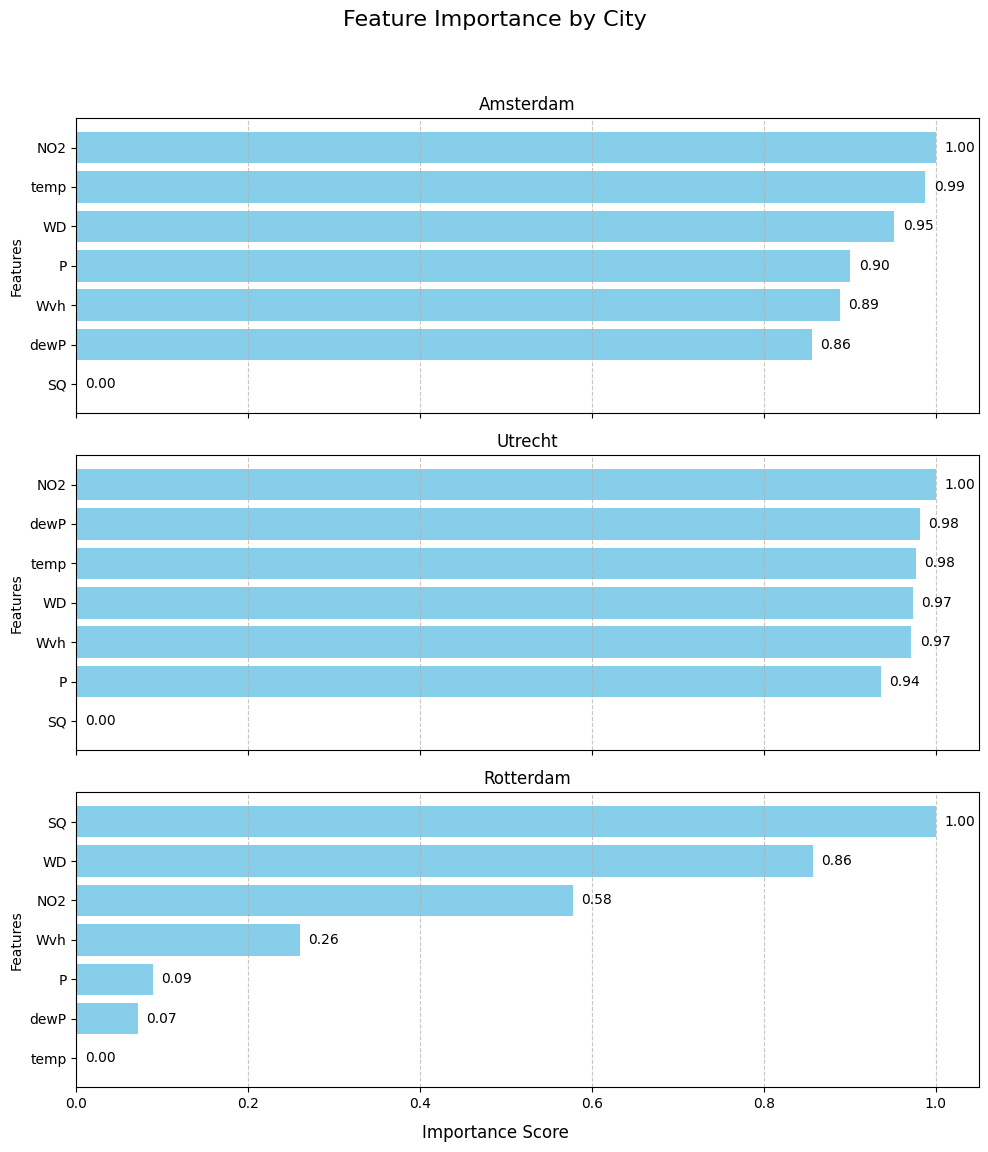

In [9]:
# Create a figure with 3 subplots (one for each city)
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig.suptitle("Feature Importance by City", fontsize=16)

# Get data from node_importances tensor
importances_np = node_importances.detach().cpu().numpy()

# Plot horizontal bar charts for each city
for i, (node_idx, city_name) in enumerate(node_names.items()):
    # Get importance values for this city
    city_importances = importances_np[i]
    
    # Sort values for better visualization (optional)
    sorted_indices = np.argsort(city_importances)
    sorted_features = [feature_names[j] for j in sorted_indices]
    sorted_importances = city_importances[sorted_indices]
    
    # Plot horizontal bars
    bars = axes[i].barh(sorted_features, sorted_importances, color='skyblue')
    
    # Add values on the bars
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                    f'{width:.2f}', va='center')
    
    # Set title and labels
    axes[i].set_title(f"{city_name}")
    axes[i].set_ylabel("Features")
    
    # Add grid lines for readability
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

# Add common x-label
fig.text(0.5, 0.04, 'Importance Score', ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust layout to make room for labels
plt.show()

# Through Integrated Gradients

In [15]:
# Improved SpatialWrapper class with better type handling
class SpatialWrapper(torch.nn.Module):
    def __init__(self, model, edge_index, edge_weight=None, lambda_max=None):
        super().__init__()
        self.model = model
        self.edge_index = edge_index
        self.edge_weight = edge_weight
        self.lambda_max = lambda_max
        
    def forward(self, x):
        # Get the dtype from the input
        dtype = x.dtype
        
        # Temporarily convert model to the input dtype
        original_model_dtype = next(self.model.parameters()).dtype
        model = self.model.to(dtype)
        
        # Convert edge data to match input dtype
        edge_index = self.edge_index
        edge_weight = self.edge_weight.to(dtype) if self.edge_weight is not None else None
        lambda_max_val = self.lambda_max
        
        # Forward pass with consistent dtypes
        try:
            # Convert input tensor to the right dtype if needed
            if x.dtype != dtype:
                x = x.to(dtype)
                
            # Run the forward pass
            output = model(x, edge_index, edge_weight, lambda_max_val)
            
            # Restore model to its original dtype
            self.model = model.to(original_model_dtype)
            
            return output
        except Exception as e:
            # Restore model dtype even on error
            self.model = model.to(original_model_dtype)
            print(f"Error in forward pass: {e}")
            print(f"Input dtype: {x.dtype}, Model dtype: {dtype}, Edge index dtype: {edge_index.dtype}")
            if edge_weight is not None:
                print(f"Edge weight dtype: {edge_weight.dtype}")
            raise

In [25]:
from captum.attr import IntegratedGradients
from tqdm import tqdm

# Double-check model's forward pass with different dtypes
x_test, _ = test_batch
print(f"Original x dtype: {x_test.dtype}")

# Try running a forward pass with float32 to check if it works
model.eval()
with torch.no_grad():
    try:
        # Convert to float32
        x_float32 = x_test.to(device=device, dtype=torch.float32)
        edge_index_float32 = edge_index.to(device)
        edge_weight_float32 = edge_weight.to(device=device, dtype=torch.float32) if edge_weight is not None else None
        
        # Test forward pass
        out_float32 = model(x_float32, edge_index_float32, edge_weight_float32, lambda_max)
        print("✓ Forward pass with float32 successful")
        print(f"Output shape: {out_float32.shape}, dtype: {out_float32.dtype}")
    except Exception as e:
        print(f"✗ Forward pass with float32 failed: {e}")

    try:
        # Convert to float64
        x_float64 = x_test.to(device=device, dtype=torch.float64)
        edge_index_float64 = edge_index.to(device)
        edge_weight_float64 = edge_weight.to(device=device, dtype=torch.float64) if edge_weight is not None else None
        
        # Test forward pass
        out_float64 = model(x_float64, edge_index_float64, edge_weight_float64, lambda_max)
        print("✓ Forward pass with float64 successful")
        print(f"Output shape: {out_float64.shape}, dtype: {out_float64.dtype}")
    except Exception as e:
        print(f"✗ Forward pass with float64 failed: {e}")

# Use the dtype that works for your model
working_dtype = torch.float32  # Change to float64 if that's what works

# Create wrapper model with the working dtype
wrapped_model = SpatialWrapper(
    model=model.to(working_dtype), 
    edge_index=edge_index, 
    edge_weight=edge_weight.to(working_dtype) if edge_weight is not None else None,
    lambda_max=lambda_max
).to(working_dtype)
wrapped_model.eval()

# Use the same dtype for inputs
x = x_test.to(device=device, dtype=working_dtype).requires_grad_()
baseline = torch.zeros_like(x, dtype=working_dtype)

# Compute attributions
N = 3  # Number of nodes
all_attributions = []
node_names = {0: "Amsterdam", 1: "Utrecht", 2: "Rotterdam"}
target_time = 0  # First forecasted timestep

for node_idx in tqdm(range(N), total=N):
    print(f"Computing attributions for node: {node_names[node_idx]}")
    
    # Define scalar-output forward function for this node
    def forward_func(x_input, target_node=node_idx):
        # Ensure input has the right dtype
        if x_input.dtype != working_dtype:
            x_input = x_input.to(dtype=working_dtype)
            
        out = wrapped_model(x_input)
        return out[:, target_time, target_node]
    
    try:
        # Use Integrated Gradients
        ig = IntegratedGradients(forward_func)
        
        # Test the forward function before attribution
        test_out = forward_func(x)
        print(f"Test output shape: {test_out.shape}, dtype: {test_out.dtype}")
        
        # Compute attribution
        node_attributions, delta = ig.attribute(
            inputs=x,
            baselines=baseline,
            return_convergence_delta=True,
            n_steps=50
        )
        
        # Store attribution
        all_attributions.append(node_attributions)
        print(f"Attribution shape: {node_attributions.shape}, dtype: {node_attributions.dtype}")
        print(f"Convergence delta: {delta.mean().item():.6f}")
    except Exception as e:
        print(f"Error computing attributions for node {node_idx}: {e}")
        # Print more detailed error information
        import traceback
        traceback.print_exc()

# Process attributions if available
if all_attributions:
    attributions = torch.stack(all_attributions, dim=0).mean(dim=0)
    print(f"Final attributions shape: {attributions.shape}")
else:
    print("No successful attributions were computed")

Original x dtype: torch.float64
✓ Forward pass with float32 successful
Output shape: torch.Size([32, 24, 3]), dtype: torch.float32
✓ Forward pass with float64 successful
Output shape: torch.Size([32, 24, 3]), dtype: torch.float32


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 16.97it/s]

Computing attributions for node: Amsterdam
Test output shape: torch.Size([32]), dtype: torch.float32
Attribution shape: torch.Size([32, 72, 21]), dtype: torch.float32
Convergence delta: -0.000060
Computing attributions for node: Utrecht
Test output shape: torch.Size([32]), dtype: torch.float32
Attribution shape: torch.Size([32, 72, 21]), dtype: torch.float32
Convergence delta: 0.000058
Computing attributions for node: Rotterdam
Test output shape: torch.Size([32]), dtype: torch.float32
Attribution shape: torch.Size([32, 72, 21]), dtype: torch.float32
Convergence delta: 0.000001
Final attributions shape: torch.Size([32, 72, 21])


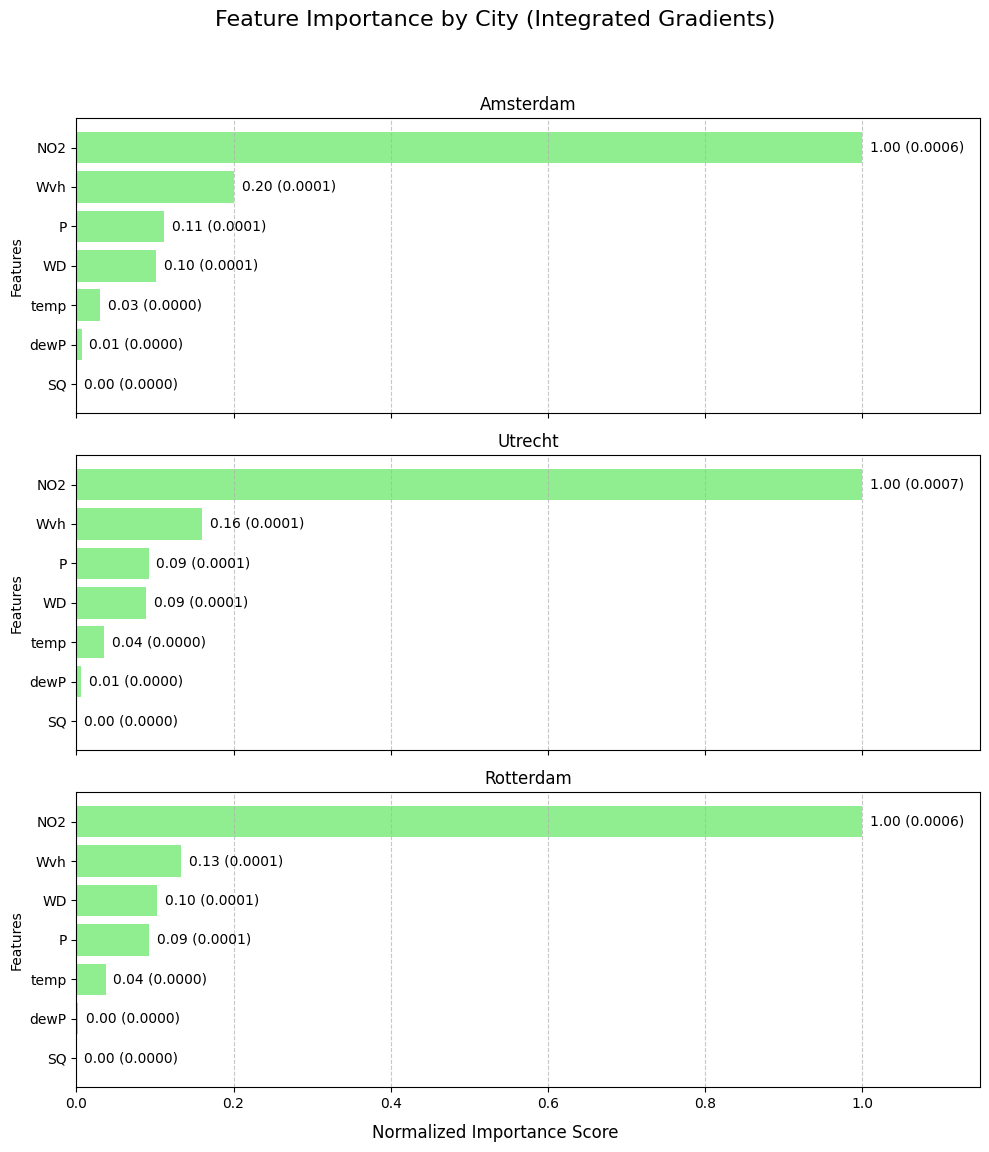

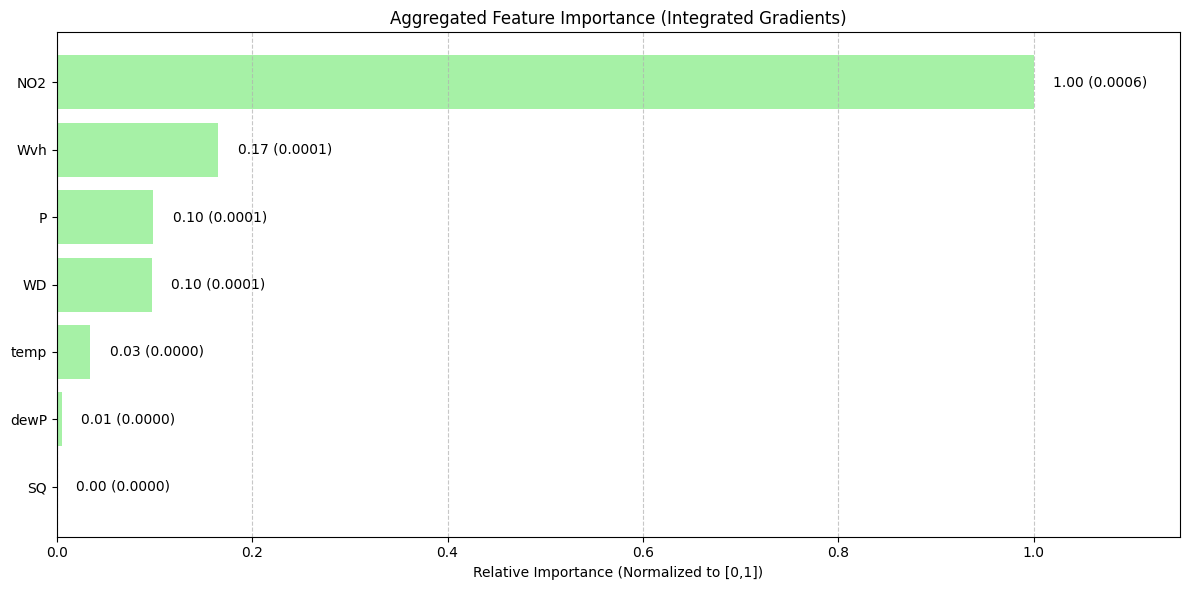

In [26]:
# Calculate feature importance from integrated gradients attributions
attr = attributions.abs()  # Use absolute values of attributions

# First reshape attributions to (B, T, N, F)
B, T, NF = attr.shape
N = 3  # Number of nodes
F = 7  # Number of features
attr_reshaped = attr.reshape(B, T, N, F)

# Average over batch and time dimensions to get node-feature importance
attr_node_feature = attr_reshaped.mean(dim=(0, 1))  # shape: (N, F)

# Feature names
feature_names = ["NO2", "P", "SQ", "WD", "Wvh", "dewP", "temp"]

# Create a figure with 3 subplots (one for each city)
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig.suptitle("Feature Importance by City (Integrated Gradients)", fontsize=16)

# Get data from attributions tensor
importances_np = attr_node_feature.detach().cpu().numpy()

# Plot horizontal bar charts for each city
for i, (node_idx, city_name) in enumerate(node_names.items()):
    # Get importance values for this city
    city_importances = importances_np[i]
    
    # Normalize to [0,1] range
    min_val = city_importances.min()
    max_val = city_importances.max()
    if max_val > min_val:
        city_importances_norm = (city_importances - min_val) / (max_val - min_val)
    else:
        city_importances_norm = city_importances - min_val
    
    # Sort values for better visualization (ascending order)
    sorted_indices = np.argsort(city_importances_norm)
    sorted_features = [feature_names[j] for j in sorted_indices]
    sorted_importances = city_importances_norm[sorted_indices]
    sorted_original = city_importances[sorted_indices]
    
    # Plot horizontal bars
    bars = axes[i].barh(sorted_features, sorted_importances, color='lightgreen')
    
    # Add values on the bars (both normalized and original)
    for j, (bar, orig) in enumerate(zip(bars, sorted_original)):
        width = bar.get_width()
        axes[i].text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                    f'{width:.2f} ({orig:.4f})', va='center')
    
    # Set title and labels
    axes[i].set_title(f"{city_name}")
    axes[i].set_ylabel("Features")
    axes[i].set_xlim(0, 1.15)  # Make room for labels
    
    # Add grid lines for readability
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

# Add common x-label
fig.text(0.5, 0.04, 'Normalized Importance Score', ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Adjust layout to make room for labels
plt.show()

# Now create an aggregated plot across all cities
plt.figure(figsize=(12, 6))

# Average across all nodes
aggregated_importance = attr_node_feature.mean(dim=0).detach().cpu().numpy()

# Normalize to [0,1] scale
if aggregated_importance.max() > aggregated_importance.min():
    normalized_importance = (aggregated_importance - aggregated_importance.min()) / (aggregated_importance.max() - aggregated_importance.min())
else:
    normalized_importance = aggregated_importance

# Sort by importance (ascending)
sorted_indices = np.argsort(normalized_importance)
sorted_importance = normalized_importance[sorted_indices]
sorted_original = aggregated_importance[sorted_indices]
sorted_features = [feature_names[idx] for idx in sorted_indices]

# Create horizontal bar chart
y_pos = np.arange(len(sorted_features))
bars = plt.barh(y_pos, sorted_importance, align='center', color='lightgreen', alpha=0.8)
plt.yticks(y_pos, sorted_features)

# Add value labels
for j, (v_norm, v_orig) in enumerate(zip(sorted_importance, sorted_original)):
    plt.text(v_norm + 0.02, j, f"{v_norm:.2f} ({v_orig:.4f})", va='center')

plt.title('Aggregated Feature Importance (Integrated Gradients)')
plt.xlabel('Relative Importance (Normalized to [0,1])')
plt.xlim(0, 1.15)  # Make room for labels
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()